# Sesión 6 — Análisis pushover monotónico incremental

## Aplicación portable: edificio didáctico de 2 pisos

Esta sesión consume el contrato estructural de la sesión 5, aplica gravedad, calibra $EI$ y $M$–$\theta(P_g)$, incorpora criterios externos, aplica un patrón triangular y ejecuta Newton–Raphson con control directo del desplazamiento promedio de techo. El resultado es la curva de capacidad $V_b$–$u_{control}$.

## 1. Formulación del paso incremental

En cada iteración se satisfacen simultáneamente

$$\mathbf r=\mathbf P_g+\lambda\mathbf P-\mathbf f_{int}(\mathbf u)=\mathbf0,$$

$$\mathbf c^T\mathbf u=u_{objetivo}.$$

Las incógnitas son la corrección de los GDL libres y el incremento del factor lateral $\lambda$. Esto es control directo de desplazamiento, no longitud de arco.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta/"temario.md").is_file() and (carpeta/"PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del curso.")

RAIZ = buscar_raiz()
PORTABLE = RAIZ/"PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))
RUTA_MAESTRA = PORTABLE/"casos"/"edificio_2pisos.json"
RUTA_C03 = RAIZ/"sesion_03"/"resultados_portable_2pisos"/"contrato_sesion03_2pisos.json"

from ejecutar_pushover import cargar_entrada_maestra, evaluar_calidad_curva, ejecutar_cadena
from sesion_03.biblioteca_rotulas import leer_contrato_sesion03
from sesion_05.contrato_portable import guardar_contrato_sesion05
from sesion_06.caso_medrano import crear_caso_gravitacional_desde_datos, resumen_cargas
from sesion_06.pushover import ConfiguracionPushover, analizar_pushover, crear_patron_lateral, guardar_resultados
from sesion_06.rotulas_axiales import calibrar_contrato_nivel1
from sesion_06.criterios_externos import aplicar_criterios_externos
from sesion_06.visualizacion import guardar_figuras

entrada, _, cargas = cargar_entrada_maestra(RUTA_MAESTRA)
c03=leer_contrato_sesion03(RUTA_C03); biblioteca=c03["biblioteca_rotulas"]
ruta_c05=RAIZ/"sesion_05"/"resultados_portable_2pisos"/"contrato_sesion05_2pisos.json"
contrato_s5=json.loads(ruta_c05.read_text(encoding="utf-8"))
print("Contrato S5:",ruta_c05.relative_to(RAIZ),"schema",contrato_s5["schema_version"])

Contrato S5: sesion_05\resultados_portable_2pisos\contrato_sesion05_2pisos.json schema 3.4


## 2. Estado gravitacional y calibración axial

La gravedad se aplica antes del empuje lateral. La carga axial obtenida en cada columna selecciona por interpolación su rigidez y su ley de rótula; el proceso gravedad → $P_g$ → $EI$ se repite hasta converger.

In [2]:
caso_gravedad=crear_caso_gravitacional_desde_datos(contrato_s5,cargas,entrada)
cfg=ConfiguracionPushover(**entrada["pushover"]["configuracion"])
asignacion={int(k):str(v) for k,v in contrato_s5["asignacion_secciones"].items()}
ccfg=entrada["calibracion"]
calibracion=calibrar_contrato_nivel1(
    contrato_s5,caso_gravedad,asignacion,biblioteca,configuracion=cfg,
    fuera_de_rango=ccfg["fuera_de_rango"],actualizar_EI=ccfg["actualizar_EI"],
    tolerancia_axial_fraccion=ccfg["tolerancia_axial_fraccion"],max_iteraciones=ccfg["max_iteraciones"],
    catalogo_secciones=entrada["secciones"])
assert calibracion["convergio"]
contrato_cal=calibracion["contrato"]
resumen_g=resumen_cargas(contrato_cal,caso_gravedad)
print("Calibración convergió en",len(calibracion["historia_calibracion"]),"iteraciones")
print(f"Carga gravitacional total: {resumen_g['carga_gravitacional_total_kgf']/1000:.3f} tf")

Calibración convergió en 2 iteraciones
Carga gravitacional total: 63.428 tf


## 3. Criterios externos y patrón lateral\n\nLos límites IO–LS–CP se leen del catálogo externo. Para dos pisos, el patrón triangular normalizado reparte fuerzas proporcionales a $[1,2]$; el factor $\lambda$ tiene unidades de kgf y representa el empuje lateral total.

In [3]:
c_crit=entrada["configuracion_criterios"]
contrato_cal=aplicar_criterios_externos(
    contrato_cal,entrada["_catalogo_criterios"],
    permitir_provisionales=c_crit["permitir_provisionales"],
    politica_exceso_capacidad=c_crit["politica_exceso_capacidad"])
n_pisos=int(contrato_cal["geometria"]["n_pisos"])
coef=np.arange(1,n_pisos+1,dtype=float)
patron=crear_patron_lateral(contrato_cal,coef)
print("Coeficientes por piso:",coef,"; suma horizontal global:",patron[0::3].sum())
assert np.isclose(patron[0::3].sum(),1.0)

Coeficientes por piso: [1. 2.] ; suma horizontal global: 1.0


## 4. Ejecución y curva de capacidad

Se incrementa el desplazamiento promedio de techo en 0.25 cm. Cada punto conserva iteraciones, residuo, cortante basal, derivas, fuerzas internas y eventos de rótula.

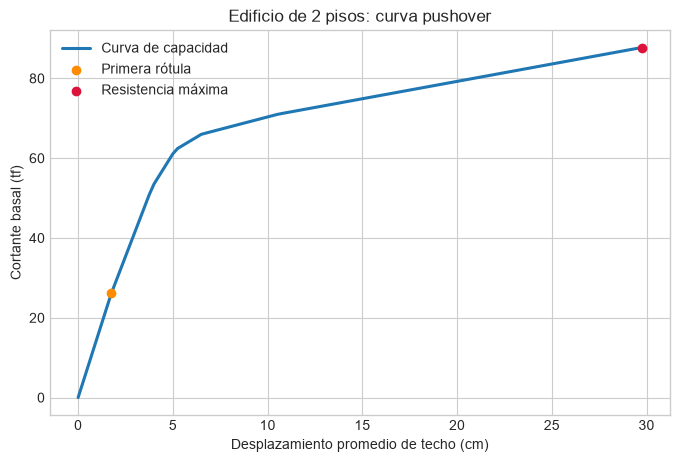

Convergió: True ; parada: limite_rotacion: E3-j, E9-j
Puntos: 120 ; rótulas formadas: 12 ; calidad aprobada: True
Final: u=29.75 cm, Vb=87.725 tf


In [4]:
resultados=analizar_pushover(contrato_cal,patron,cargas_gravitacionales=caso_gravedad,configuracion=cfg)
calidad=evaluar_calidad_curva(resultados,entrada["pushover"]["calidad_curva"])
resultados["calidad_curva"]=calidad
hist=resultados["historia"]
u=np.array([h["desplazamiento_control_cm"] for h in hist])
V=np.array([h["cortante_basal_kgf"] for h in hist])
formaciones=[e for e in resultados["eventos"] if e["tipo"]=="formacion_rotula"]
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(u,V/1000,lw=2.2,label="Curva de capacidad")
if formaciones:
    e=formaciones[0]; ax.scatter(e["desplazamiento_control_cm"],e["cortante_basal_kgf"]/1000,
        color="darkorange",zorder=4,label="Primera rótula")
imax=int(np.argmax(V)); ax.scatter(u[imax],V[imax]/1000,color="crimson",zorder=4,label="Resistencia máxima")
ax.set(xlabel="Desplazamiento promedio de techo (cm)",ylabel="Cortante basal (tf)",
       title="Edificio de 2 pisos: curva pushover")
ax.legend(); plt.show()
print("Convergió:",resultados["convergio"],"; parada:",resultados["razon_parada"])
print("Puntos:",len(hist),"; rótulas formadas:",len(formaciones),"; calidad aprobada:",calidad["aprobada"])
print(f"Final: u={u[-1]:.2f} cm, Vb={V[-1]/1000:.3f} tf")
assert resultados["convergio"] and calidad["aprobada"]

## 5. Derivas y secuencia no lineal

Una curva convergente no basta: se revisan derivas, formación de rótulas y mecanismo. La aparición de una rótula no equivale automáticamente a colapso.

In [5]:
print(f"{'Paso':>5} {'u techo':>9} {'Vb (tf)':>9} {'deriva máx':>12} {'iter':>6} {'eventos':>8}")
for h in hist[::max(1,len(hist)//10)]:
    print(f"{h['paso']:5d} {h['desplazamiento_control_cm']:9.2f} {h['cortante_basal_kgf']/1000:9.3f} "
          f"{h['deriva_maxima']:12.5f} {h['iteraciones']:6d} {len(h['eventos_no_lineales']):8d}")
print("Primeras formaciones:")
for e in formaciones[:8]: print(e["paso"],e["rotula"],f"u={e['desplazamiento_control_cm']:.2f} cm",f"Vb={e['cortante_basal_kgf']/1000:.3f} tf")

 Paso   u techo   Vb (tf)   deriva máx   iter  eventos
    0      0.00     0.000      0.00000     10        0
   12      3.00    41.530      0.00650      2        0
   24      6.00    64.543      0.01262      2        0
   36      9.00    69.081      0.01761      2        0
   48     12.00    72.271      0.02269      2        0
   60     15.00    74.883      0.02786      2        0
   72     18.00    77.495      0.03304      2        0
   84     21.00    80.107      0.03821      2        0
   96     24.00    82.719      0.04338      2        0
  108     27.00    85.331      0.04855      2        0
Primeras formaciones:
7 E6-j u=1.75 cm Vb=26.078 tf
8 E12-j u=2.00 cm Vb=29.173 tf
16 E3-j u=4.00 cm Vb=53.478 tf
16 E9-j u=4.00 cm Vb=53.478 tf
20 E8-i u=5.00 cm Vb=61.087 tf
21 E1-i u=5.25 cm Vb=62.412 tf
21 E2-i u=5.25 cm Vb=62.412 tf
21 E7-i u=5.25 cm Vb=62.412 tf


## 6. Exportación de resultados

Se guardan el contrato calibrado, la historia completa y las mismas tres figuras que produce el sistema integrado.

In [6]:
salida=RAIZ/"sesion_06"/"resultados_portable_2pisos"; salida.mkdir(parents=True,exist_ok=True)
guardar_contrato_sesion05(contrato_cal,salida/"contrato_sesion05_calibrado_2pisos.json")
guardar_resultados(resultados,salida/"resultados_pushover_2pisos.json")
guardar_figuras(contrato_cal,resultados,salida)
print("Resultados guardados en:",salida.relative_to(RAIZ))

Resultados guardados en: sesion_06\resultados_portable_2pisos


## 7. Verificación contra el ejecutor integrado

Se ejecuta `ejecutar_pushover.py` en una carpeta de referencia y se comparan punto por punto desplazamiento y cortante basal. Esta es la comprobación de que la cadena didáctica reproduce el sistema de computación.

In [7]:
salida_ref=RAIZ/"sesion_06"/"referencia_integrada_2pisos"
informe_ref=ejecutar_cadena(RUTA_MAESTRA,salida_ref)
ref=json.loads((salida_ref/"sesion_06"/"resultados_pushover.json").read_text(encoding="utf-8"))
u_ref=np.array([h["desplazamiento_control_cm"] for h in ref["historia"]])
V_ref=np.array([h["cortante_basal_kgf"] for h in ref["historia"]])
assert len(u)==len(u_ref)
du=np.max(np.abs(u-u_ref)); dV=np.max(np.abs(V-V_ref))
print(f"Diferencia máxima en desplazamiento: {du:.3e} cm")
print(f"Diferencia máxima en cortante basal: {dV:.3e} kgf")
print("Coincidencia punto por punto:",np.allclose(u,u_ref,rtol=0,atol=1e-10) and np.allclose(V,V_ref,rtol=1e-12,atol=1e-8))
assert np.allclose(u,u_ref,rtol=0,atol=1e-10)
assert np.allclose(V,V_ref,rtol=1e-12,atol=1e-8)

Diferencia máxima en desplazamiento: 0.000e+00 cm
Diferencia máxima en cortante basal: 0.000e+00 kgf
Coincidencia punto por punto: True


## 8. Cierre y limitaciones

La curva del curso y la del ejecutor integrado son numéricamente idénticas porque usan los mismos JSON, contratos y módulos. El modelo sigue siendo 2D, de primer orden, con plasticidad concentrada; no incluye P–Delta, torsión 3D, degradación cíclica ni comprobación frágil automática por cortante. Para una estructura real se requiere revisión profesional y contraste con planos, ensayos y normativa vigente.

---

# Parte B — Curva pushover de `MI_EDIFICIO`

Esta parte completa la cadena personalizada: gravedad, calibración axial, criterios externos, patrón lateral, control por desplazamiento y curva de capacidad. Los resultados quedan en `resultados_curso_portable/<caso_id>/sesion_06/`.

> Los criterios incluidos en la plantilla son provisionales para docencia; deben sustituirse y justificarse antes de interpretar un edificio real.

In [8]:
EJECUTAR_MI_EDIFICIO = False
RUTA_MAESTRA_MI = PORTABLE / "casos" / "MI_EDIFICIO" / "entrada_maestra.json"

if not EJECUTAR_MI_EDIFICIO:
    print("Práctica MI_EDIFICIO desactivada. Actívala cuando exista el contrato personalizado de la sesión 5.")
else:
    entrada_mi, _, cargas_mi = cargar_entrada_maestra(RUTA_MAESTRA_MI)
    caso_id_mi = str(entrada_mi["caso_id"]).strip()
    if "CAMBIAR" in caso_id_mi.upper():
        raise ValueError("Reemplaza MI_EDIFICIO_CAMBIAR por un caso_id propio.")
    BASE_MI = RAIZ / "resultados_curso_portable" / caso_id_mi
    RUTA_C03_MI = BASE_MI / "sesion_03" / "contrato_sesion03.json"
    RUTA_C05_MI = BASE_MI / "sesion_05" / "contrato_sesion05.json"
    if not RUTA_C03_MI.is_file() or not RUTA_C05_MI.is_file():
        raise FileNotFoundError("Primero ejecuta las Partes B de las sesiones 3 y 5.")
    biblioteca_mi = leer_contrato_sesion03(RUTA_C03_MI)["biblioteca_rotulas"]
    contrato_s5_mi = json.loads(RUTA_C05_MI.read_text(encoding="utf-8"))

Práctica MI_EDIFICIO desactivada. Actívala cuando exista el contrato personalizado de la sesión 5.


In [9]:
if EJECUTAR_MI_EDIFICIO:
    caso_gravedad_mi = crear_caso_gravitacional_desde_datos(contrato_s5_mi, cargas_mi, entrada_mi)
    cfg_mi = ConfiguracionPushover(**entrada_mi["pushover"].get("configuracion", {}))
    asignacion_mi = {int(k): str(v) for k, v in contrato_s5_mi["asignacion_secciones"].items()}
    ccfg_mi = entrada_mi.get("calibracion", {})
    calibracion_mi = calibrar_contrato_nivel1(
        contrato_s5_mi, caso_gravedad_mi, asignacion_mi, biblioteca_mi,
        configuracion=cfg_mi,
        fuera_de_rango=str(ccfg_mi.get("fuera_de_rango", "error")),
        actualizar_EI=bool(ccfg_mi.get("actualizar_EI", True)),
        tolerancia_axial_fraccion=float(ccfg_mi.get("tolerancia_axial_fraccion", 0.01)),
        max_iteraciones=int(ccfg_mi.get("max_iteraciones", 20)),
        catalogo_secciones=entrada_mi["secciones"],
    )
    if not calibracion_mi["convergio"]:
        raise RuntimeError("La calibración axial de MI_EDIFICIO no convergió.")
    contrato_cal_mi = calibracion_mi["contrato"]
    crit_mi = entrada_mi.get("configuracion_criterios", {})
    contrato_cal_mi = aplicar_criterios_externos(
        contrato_cal_mi, entrada_mi["_catalogo_criterios"],
        permitir_provisionales=bool(crit_mi.get("permitir_provisionales", False)),
        politica_exceso_capacidad=str(crit_mi.get("politica_exceso_capacidad", "error")),
    )

In [10]:
if EJECUTAR_MI_EDIFICIO:
    n_pisos_mi = int(contrato_cal_mi["geometria"]["n_pisos"])
    definicion_mi = entrada_mi["pushover"].get("patron_lateral", "triangular")
    if isinstance(definicion_mi, list):
        coef_mi = np.asarray(definicion_mi, dtype=float)
    elif definicion_mi == "triangular":
        coef_mi = np.arange(1, n_pisos_mi + 1, dtype=float)
    elif definicion_mi == "uniforme":
        coef_mi = np.ones(n_pisos_mi)
    else:
        raise ValueError("patron_lateral debe ser triangular, uniforme o una lista.")
    patron_mi = crear_patron_lateral(contrato_cal_mi, coef_mi)
    resultados_mi = analizar_pushover(
        contrato_cal_mi, patron_mi,
        cargas_gravitacionales=caso_gravedad_mi, configuracion=cfg_mi,
    )
    resultados_mi["calidad_curva"] = evaluar_calidad_curva(
        resultados_mi, entrada_mi["pushover"].get("calidad_curva", {})
    )
    salida_mi = BASE_MI / "sesion_06"
    salida_mi.mkdir(parents=True, exist_ok=True)
    guardar_contrato_sesion05(contrato_cal_mi, BASE_MI / "sesion_05" / "contrato_sesion05_calibrado.json")
    guardar_resultados(resultados_mi, salida_mi / "resultados_pushover.json")
    guardar_figuras(contrato_cal_mi, resultados_mi, salida_mi)
    hist_mi = resultados_mi["historia"]
    u_mi = np.array([p["desplazamiento_control_cm"] for p in hist_mi])
    V_mi = np.array([p["cortante_basal_kgf"] for p in hist_mi])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(u_mi, V_mi / 1000, lw=2.2)
    ax.set(xlabel="Desplazamiento de control (cm)", ylabel="Cortante basal (tf)",
           title=f"Curva pushover — {caso_id_mi}")
    plt.show()
    print("Parada:", resultados_mi["razon_parada"], "| puntos:", len(hist_mi))
    print(f"Final: u={u_mi[-1]:.2f} cm, Vb={V_mi[-1]/1000:.3f} tf")
    print("Resultados:", salida_mi.relative_to(RAIZ))